# UFC Predictor

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import config

In [142]:
import warnings
warnings.filterwarnings('ignore')

In [143]:
pd.set_option("display.max_columns", None, "display.max_rows", None)

In [144]:
sns.set_palette('Set2')

## fight_stats

In [145]:
# Import data
fight_stats = pd.read_csv(config.PATH + '/ufc-stats/data/scraped_data/fight_stats_raw.csv')

fight_stats.head()

,Unnamed: 0,date,location,weight_class,title,method,round,time,time_format,ref,details,red_outcome,blue_outcome,red_nickname,blue_nickname,red_fighter,blue_fighter,red_fighter_kd,blue_fighter_kd,red_fighter_sig_str,blue_fighter_sig_str,red_fighter_sig_str_perc,blue_fighter_sig_str_perc,red_fighter_total_str,blue_fighter_total_str,red_fighter_td,blue_fighter_td,red_fighter_td_perc,blue_fighter_td_perc,red_fighter_sub_att,blue_fighter_sub_att,red_fighter_rev,blue_fighter_rev,red_fighter_ctrl,blue_fighter_ctrl,red_fighter_sig_str_head,blue_fighter_sig_str_head,red_fighter_sig_str_body,blue_fighter_sig_str_body,red_fighter_sig_str_leg,blue_fighter_sig_str_leg,red_fighter_sig_str_distance,blue_fighter_sig_str_distance,red_fighter_sig_str_clinch,blue_fighter_sig_str_clinch,red_fighter_sig_str_ground,blue_fighter_sig_str_ground,red_fighter_url,blue_fighter_url
0,0,"February 07, 2026","Las Vegas, Nevada, USA",Bantamweight,Bantamweight Bout,Submission,2,4,5 Rnd (5-5-5-5-5),Herb Dean,Rear Naked Choke,W,NaN,L,"""LokDog""",Mario Bautista,Vinicius Oliveira,0.0,0.0,15 of 27,12 of 21,55%,57%,49 of 63,18 of 27,5 of 7,0 of 1,71%,0%,1.0,0.0,0.0,0.0,5:47,1:39,10 of 20,3 of 10,5 of 6,3 of 5,0 of 1,6 of 6,6 of 12,9 of 18,0 of 2,3 of 3,9 of 13,0 of 0,http://ufcstats.com/fighter-details/bc711b6dd9...,http://ufcstats.com/fighter-details/18d01f7f83...
1,1,"February 07, 2026","Las Vegas, Nevada, USA",Flyweight,Flyweight Bout,Decision - Unanimous,3,5,3 Rnd (5-5-5),Keith Peterson,Eric Colon27 - 30.Junichiro Kamijo27 - 30.Ron ...,L,"""The Prince""",W,"""Karate Kid""",Amir Albazi,Kyoji Horiguchi,0.0,0.0,16 of 67,73 of 136,23%,53%,20 of 75,99 of 163,0 of 7,0 of 2,0%,0%,0.0,0.0,0.0,0.0,3:50,1:02,12 of 62,65 of 123,4 of 5,3 of 6,0 of 0,5 of 7,12 of 60,71 of 133,4 of 6,2 of 3,0 of 1,0 of 0,http://ufcstats.com/fighter-details/6d35bf94f7...,http://ufcstats.com/fighter-details/98aa60cf58...
2,2,"February 07, 2026","Las Vegas, Nevada, USA",Heavyweight,Heavyweight Bout,Decision - Unanimous,3,5,3 Rnd (5-5-5),Dan Miragliotta,Mike Bell27 - 30.Sal D'amato27 - 30.Chris Lee2...,L,"""Malhadinho""",W,NaN,Jailton Almeida,Rizvan Kuniev,0.0,0.0,31 of 67,43 of 93,46%,46%,50 of 92,102 of 153,0 of 8,0 of 0,0%,---,0.0,0.0,0.0,0.0,1:24,6:35,17 of 50,31 of 77,12 of 15,11 of 15,2 of 2,1 of 1,23 of 57,22 of 65,8 of 10,21 of 28,0 of 0,0 of 0,http://ufcstats.com/fighter-details/41e83a8992...,http://ufcstats.com/fighter-details/739fd4fbb5...
3,3,"February 07, 2026","Las Vegas, Nevada, USA",Middleweight,Middleweight Bout,Decision - Unanimous,3,5,3 Rnd (5-5-5),Chris Tognoni,Eric Colon28 - 29.Junichiro Kamijo28 - 29.Ron ...,W,"""Hussar""",L,"""Powerbar""",Michal Oleksiejczuk,Marc-Andre Barriault,0.0,0.0,140 of 221,77 of 201,63%,38%,143 of 225,79 of 204,1 of 3,0 of 0,33%,---,0.0,0.0,0.0,0.0,0:30,0:02,91 of 161,57 of 178,39 of 49,16 of 19,10 of 11,4 of 4,138 of 218,59 of 173,1 of 1,18 of 28,1 of 2,0 of 0,http://ufcstats.com/fighter-details/0d65c43272...,http://ufcstats.com/fighter-details/8e9eb3fc86...
4,4,"February 07, 2026","Las Vegas, Nevada, USA",Bantamweight,Bantamweight Bout,Decision - Split,3,5,3 Rnd (5-5-5),Herb Dean,Mike Bell28 - 29.Ron McCarthy29 - 28.Sal D'ama...,L,NaN,W,"""Ferocious""",Jean Matsumoto,Farid Basharat,0.0,0.0,76 of 220,80 of 152,34%,52%,111 of 263,95 of 172,7 of 11,2 of 7,63%,28%,0.0,0.0,0.0,1.0,4:40,2:23,40 of 162,63 of 132,20 of 29,14 of 16,16 of 29,3 of 4,62 of 197,66 of 136,14 of 23,14 of 16,0 of 0,0 of 0,http://ufcstats.com/fighter-details/ffd3224638...,http://ufcstats.com/fighter-details/a09ed60aa6...


In [146]:
# Column titles
print("Columns\n=======")
print(list(fight_stats.columns))

Columns
['Unnamed: 0', 'date', 'location', 'weight_class', 'title', 'method', 'round', 'time', 'time_format', 'ref', 'details', 'red_outcome', 'blue_outcome', 'red_nickname', 'blue_nickname', 'red_fighter', 'blue_fighter', 'red_fighter_kd', 'blue_fighter_kd', 'red_fighter_sig_str', 'blue_fighter_sig_str', 'red_fighter_sig_str_perc', 'blue_fighter_sig_str_perc', 'red_fighter_total_str', 'blue_fighter_total_str', 'red_fighter_td', 'blue_fighter_td', 'red_fighter_td_perc', 'blue_fighter_td_perc', 'red_fighter_sub_att', 'blue_fighter_sub_att', 'red_fighter_rev', 'blue_fighter_rev', 'red_fighter_ctrl', 'blue_fighter_ctrl', 'red_fighter_sig_str_head', 'blue_fighter_sig_str_head', 'red_fighter_sig_str_body', 'blue_fighter_sig_str_body', 'red_fighter_sig_str_leg', 'blue_fighter_sig_str_leg', 'red_fighter_sig_str_distance', 'blue_fighter_sig_str_distance', 'red_fighter_sig_str_clinch', 'blue_fighter_sig_str_clinch', 'red_fighter_sig_str_ground', 'blue_fighter_sig_str_ground', 'red_fighter_url',

In [147]:
def get_perc(x: str) -> float:
    '''
    Args:
    x (string): text in the format <landed> of <total>

    Returns:
    float: percentage (0 to 1) landed / total 
    '''
    if not isinstance(x, str):
        return np.nan
    try:
        y = x.split(' of ')
        if len(y) == 2:
            landed, total = int(y[0]), int(y[1])
            if total > 0:
                return round(landed / total, 2)
            return 0
    except (ValueError, TypeError):
        return np.nan

In [148]:
def get_attempts(x: str) -> int:
    '''
    Args:
    x (string): text in the format <landed> of <attempts>

    Returns:
    int: attempts
    '''
    if not isinstance(x, str):
        return np.nan
    try:
        return int(x.split(' of ')[1])
    except (ValueError, AttributeError, TypeError):
        return np.nan

In [149]:
def time_format_to_rounds(x: str) -> int:
    '''
    Args:
    x (string): time format of the fight

    Returns:
    int: maximum number of rounds in the fight
    '''
    if not isinstance(x, str):
        return np.nan    
    if x == 'No Time Limit':
        return 5
    try:
        return int(x[0])
    except (ValueError):
        return np.nan

In [150]:
def mins_per_round(x: str) -> int:
    '''
    Args:
    x (string): time format

    Returns:
    int: time limit (mins) per round in the fight
    '''
    if not isinstance(x, str):
        return np.nan
    try:
        mins = re.findall(r'\(([\d\-]*)\)', x)
        if len(mins):
            mins = mins[0].split('-')
            if len(set(mins)) == 1:
                return int(mins[0])
        return np.nan
    except (ValueError, TypeError):
        return np.nan

In [151]:
# Columns with the format '<landed> of <attempts>'
cols = ['blue_fighter_sig_str', 'red_fighter_sig_str',
        'blue_fighter_total_str', 'red_fighter_total_str',
        'blue_fighter_td', 'red_fighter_td',
        'blue_fighter_sig_str_head', 'red_fighter_sig_str_head',
        'blue_fighter_sig_str_body', 'red_fighter_sig_str_body',
        'blue_fighter_sig_str_leg', 'red_fighter_sig_str_leg',
        'blue_fighter_sig_str_distance', 'red_fighter_sig_str_distance',
        'blue_fighter_sig_str_clinch', 'red_fighter_sig_str_clinch',
        'blue_fighter_sig_str_ground', 'red_fighter_sig_str_ground']

for col in cols:
    fight_stats[col] = fight_stats[col].fillna('0 of 0') # Fill null values
    fight_stats[col + '_perc'] = fight_stats[col].map(lambda x: get_perc(x)) # percentage column
    fight_stats[col + '_att'] = fight_stats[col].map(lambda x: get_attempts(x)) # attempts column
        
# Drop columns
fight_stats = fight_stats.drop(columns=cols)

fight_stats.head()

,Unnamed: 0,date,location,weight_class,title,method,round,time,time_format,ref,details,red_outcome,blue_outcome,red_nickname,blue_nickname,red_fighter,blue_fighter,red_fighter_kd,blue_fighter_kd,red_fighter_sig_str_perc,blue_fighter_sig_str_perc,red_fighter_td_perc,blue_fighter_td_perc,red_fighter_sub_att,blue_fighter_sub_att,red_fighter_rev,blue_fighter_rev,red_fighter_ctrl,blue_fighter_ctrl,red_fighter_url,blue_fighter_url,blue_fighter_sig_str_att,red_fighter_sig_str_att,blue_fighter_total_str_perc,blue_fighter_total_str_att,red_fighter_total_str_perc,red_fighter_total_str_att,blue_fighter_td_att,red_fighter_td_att,blue_fighter_sig_str_head_perc,blue_fighter_sig_str_head_att,red_fighter_sig_str_head_perc,red_fighter_sig_str_head_att,blue_fighter_sig_str_body_perc,blue_fighter_sig_str_body_att,red_fighter_sig_str_body_perc,red_fighter_sig_str_body_att,blue_fighter_sig_str_leg_perc,blue_fighter_sig_str_leg_att,red_fighter_sig_str_leg_perc,red_fighter_sig_str_leg_att,blue_fighter_sig_str_distance_perc,blue_fighter_sig_str_distance_att,red_fighter_sig_str_distance_perc,red_fighter_sig_str_distance_att,blue_fighter_sig_str_clinch_perc,blue_fighter_sig_str_clinch_att,red_fighter_sig_str_clinch_perc,red_fighter_sig_str_clinch_att,blue_fighter_sig_str_ground_perc,blue_fighter_sig_str_ground_att,red_fighter_sig_str_ground_perc,red_fighter_sig_str_ground_att
0,0,"February 07, 2026","Las Vegas, Nevada, USA",Bantamweight,Bantamweight Bout,Submission,2,4,5 Rnd (5-5-5-5-5),Herb Dean,Rear Naked Choke,W,NaN,L,"""LokDog""",Mario Bautista,Vinicius Oliveira,0.0,0.0,0.56,0.57,0.71,0.00,1.0,0.0,0.0,0.0,5:47,1:39,http://ufcstats.com/fighter-details/bc711b6dd9...,http://ufcstats.com/fighter-details/18d01f7f83...,21,27,0.67,27,0.78,63,1,7,0.30,10,0.50,20,0.60,5,0.83,6,1.00,6,0.00,1,0.50,18,0.50,12,1.00,3,0.00,2,0.0,0,0.69,13
1,1,"February 07, 2026","Las Vegas, Nevada, USA",Flyweight,Flyweight Bout,Decision - Unanimous,3,5,3 Rnd (5-5-5),Keith Peterson,Eric Colon27 - 30.Junichiro Kamijo27 - 30.Ron ...,L,"""The Prince""",W,"""Karate Kid""",Amir Albazi,Kyoji Horiguchi,0.0,0.0,0.24,0.54,0.00,0.00,0.0,0.0,0.0,0.0,3:50,1:02,http://ufcstats.com/fighter-details/6d35bf94f7...,http://ufcstats.com/fighter-details/98aa60cf58...,136,67,0.61,163,0.27,75,2,7,0.53,123,0.19,62,0.50,6,0.80,5,0.71,7,0.00,0,0.53,133,0.20,60,0.67,3,0.67,6,0.0,0,0.00,1
2,2,"February 07, 2026","Las Vegas, Nevada, USA",Heavyweight,Heavyweight Bout,Decision - Unanimous,3,5,3 Rnd (5-5-5),Dan Miragliotta,Mike Bell27 - 30.Sal D'amato27 - 30.Chris Lee2...,L,"""Malhadinho""",W,NaN,Jailton Almeida,Rizvan Kuniev,0.0,0.0,0.46,0.46,0.00,0.00,0.0,0.0,0.0,0.0,1:24,6:35,http://ufcstats.com/fighter-details/41e83a8992...,http://ufcstats.com/fighter-details/739fd4fbb5...,93,67,0.67,153,0.54,92,0,8,0.40,77,0.34,50,0.73,15,0.80,15,1.00,1,1.00,2,0.34,65,0.40,57,0.75,28,0.80,10,0.0,0,0.00,0
3,3,"February 07, 2026","Las Vegas, Nevada, USA",Middleweight,Middleweight Bout,Decision - Unanimous,3,5,3 Rnd (5-5-5),Chris Tognoni,Eric Colon28 - 29.Junichiro Kamijo28 - 29.Ron ...,W,"""Hussar""",L,"""Powerbar""",Michal Oleksiejczuk,Marc-Andre Barriault,0.0,0.0,0.63,0.38,0.33,0.00,0.0,0.0,0.0,0.0,0:30,0:02,http://ufcstats.com/fighter-details/0d65c43272...,http://ufcstats.com/fighter-details/8e9eb3fc86...,201,221,0.39,204,0.64,225,0,3,0.32,178,0.57,161,0.84,19,0.80,49,1.00,4,0.91,11,0.34,173,0.63,218,0.64,28,1.00,1,0.0,0,0.50,2
4,4,"February 07, 2026","Las Vegas, Nevada, USA",Bantamweight,Bantamweight Bout,Decision - Split,3,5,3 Rnd (5-5-5),Herb Dean,Mike Bell28 - 29.Ron McCarthy29 - 28.Sal D'ama...,L,NaN,W,"""Ferocious""",Jean Matsumoto,Farid Basharat,0.0,0.0,0.35,0.53,0.64,0.29,0.0,0.0,0.0,1.0,4:40,2:23,http://ufcstats.com/fighter-details/ffd3224638...,http://ufcstats.com/fighter-details/a09ed60aa6...,152,220,0.55,172,0.42,263,7,11,0.48,132,0.25,162,0.88,16,0.69,29,0.75,4,0.55,29,0.49,136,0.31,197,0.88,16,0.61,23,0.0,0,0.00,0


In [152]:
# Convert date column to datetime
fight_stats.date = fight_stats.date.map(lambda x: pd.to_datetime(x, format='%B %d, %Y'))

In [153]:
# Column containing maximum number of rounds in the fight
fight_stats['fight_num_rounds'] = fight_stats.time_format.map(lambda x: time_format_to_rounds(x))

# Column containing the time limit of each round 
fight_stats['round_mins'] = fight_stats.time_format.map(lambda x: mins_per_round(x))

# Fills null values in round_mins with the most common round time limit
fight_stats = fight_stats.fillna({'round_mins': fight_stats['round_mins'].mode()[0]})

# Drop time_format column
fight_stats = fight_stats.drop(columns='time_format')

In [154]:
def get_score_dif(x: str) -> int:
    '''
    Args:
    x (string): text containing fight details

    Returns:
    int: difference between the blue fighter and red fighters scores
    '''
    if not isinstance(x, str):
        return np.nan
    try:
        scores = re.findall('[0-9]{2}', x)
        if len(scores) == 6:
            blue_total = int(scores[0]) + int(scores[2]) + int(scores[4])
            red_total = int(scores[1]) + int(scores[3]) + int(scores[5])
            return blue_total - red_total
        return np.nan
    except (ValueError, TypeError):
        return np.nan

In [155]:
print("Unique values in red_outcome:", list(fight_stats.red_outcome.unique()))

Unique values in red_outcome: ['W', 'L', 'D', 'NC']


In [156]:
# Create outcome column with 'red' if red wins, 'blue' if blue wins, 'draw' if the fight is a draw and 'nc' if no contest
fight_stats['outcome'] = fight_stats.red_outcome.replace({'W': 'red', 'L': 'blue', 'D': 'draw', 'NC': 'nc'})

# Drop red_outcome and blue_outcome
fight_stats.drop(columns=['red_outcome', 'blue_outcome'], inplace=True)

In [157]:
# Score difference column
fight_stats['score_dif'] = fight_stats.details.map(lambda x: get_score_dif(x)) * fight_stats.outcome.replace({'red': 1, 'blue': 1, 'draw': 0, 'nc': 0})

In [158]:
print("Unique values in method:", list(fight_stats.method.unique()))

Unique values in method: ['Submission', 'Decision - Unanimous', 'Decision - Split', 'KO/TKO', 'Decision - Majority', 'Could Not Continue', 'Overturned', "TKO - Doctor's Stoppage", 'DQ', 'Other']


In [159]:
fight_stats['title'] = fight_stats['title'].str.lower()
fight_stats['rtufc'] = fight_stats.title.map(lambda x: 1 if re.search(r'^road *to *ufc', x) else 0)
fight_stats['gender'] = fight_stats.title.map(lambda x: 0 if re.search(r"women's", x) else 1)
fight_stats['tournament'] = fight_stats.title.map(lambda x: 1 if re.search(r'tournament', x) else 0)
fight_stats['title_bout'] = fight_stats.title.map(lambda x: 1 if re.search(r'title *bout', x) else 0)
fight_stats['interim_title_bout'] = fight_stats.title.map(lambda x: 1 if re.search(r'interim *title *bout', x) else 0)

In [160]:
# fight_stats['title'] = fight_stats['title'].str.lower()
# fight_stats['title'] = fight_stats['title'].str.replace(r'^road to ufc \d* *', '', regex=True)
# fight_stats['title'] = fight_stats['title'].str.replace(r" *women's *", '', regex=True)
# fight_stats['title'] = fight_stats['title'].str.replace(r" *ultimate *fighter *\d*", '', regex=True)
# fight_stats['title'] = fight_stats['title'].str.replace(r" *title *bout *", '', regex=True)
# fight_stats['title'] = fight_stats['title'].str.replace(r" *tournament *", '', regex=True)
# fight_stats['title'] = fight_stats['title'].str.replace(r" *interim *", '', regex=True)
# fight_stats['title'] = fight_stats['title'].str.strip()

In [161]:
fight_stats.isna().sum()

Unnamed: 0                               0
date                                     0
location                                 0
weight_class                             0
title                                    0
method                                   0
round                                    0
time                                     0
ref                                     26
details                                 78
red_nickname                             0
blue_nickname                         2441
red_fighter                              0
blue_fighter                             0
red_fighter_kd                          21
blue_fighter_kd                         21
red_fighter_sig_str_perc                 0
blue_fighter_sig_str_perc                0
red_fighter_td_perc                      0
blue_fighter_td_perc                     0
red_fighter_sub_att                     21
blue_fighter_sub_att                    21
red_fighter_rev                         21
blue_fighte

In [162]:
fight_stats[fight_stats['red_fighter_ctrl'].isnull()]

,Unnamed: 0,date,location,weight_class,title,method,round,time,ref,details,red_nickname,blue_nickname,red_fighter,blue_fighter,red_fighter_kd,blue_fighter_kd,red_fighter_sig_str_perc,blue_fighter_sig_str_perc,red_fighter_td_perc,blue_fighter_td_perc,red_fighter_sub_att,blue_fighter_sub_att,red_fighter_rev,blue_fighter_rev,red_fighter_ctrl,blue_fighter_ctrl,red_fighter_url,blue_fighter_url,blue_fighter_sig_str_att,red_fighter_sig_str_att,blue_fighter_total_str_perc,blue_fighter_total_str_att,red_fighter_total_str_perc,red_fighter_total_str_att,blue_fighter_td_att,red_fighter_td_att,blue_fighter_sig_str_head_perc,blue_fighter_sig_str_head_att,red_fighter_sig_str_head_perc,red_fighter_sig_str_head_att,blue_fighter_sig_str_body_perc,blue_fighter_sig_str_body_att,red_fighter_sig_str_body_perc,red_fighter_sig_str_body_att,blue_fighter_sig_str_leg_perc,blue_fighter_sig_str_leg_att,red_fighter_sig_str_leg_perc,red_fighter_sig_str_leg_att,blue_fighter_sig_str_distance_perc,blue_fighter_sig_str_distance_att,red_fighter_sig_str_distance_perc,red_fighter_sig_str_distance_att,blue_fighter_sig_str_clinch_perc,blue_fighter_sig_str_clinch_att,red_fighter_sig_str_clinch_perc,red_fighter_sig_str_clinch_att,blue_fighter_sig_str_ground_perc,blue_fighter_sig_str_ground_att,red_fighter_sig_str_ground_perc,red_fighter_sig_str_ground_att,fight_num_rounds,round_mins,outcome,score_dif,rtufc,gender,tournament,title_bout,interim_title_bout
8360,8360,1998-10-16,"Sao Paulo, Brazil",Lightweight,lightweight bout,KO/TKO,1,10,John McCarthy,to,L,NaN,http://ufcstats.com/fighter-details/e8efeb9cf3...,http://ufcstats.com/fighter-details/7ca4c3f8aa...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,0,0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,1,5.0,red,NaN,0,1,0,0,0
8368,8368,1998-05-15,"Mobile, Alabama, USA",Heavyweight,heavyweight bout,Decision - Unanimous,2,3,John McCarthy,NaN,L,"""Dirty""",http://ufcstats.com/fighter-details/a54a35a670...,http://ufcstats.com/fighter-details/4dc496aa0c...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,0,0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,1,5.0,red,NaN,0,1,0,0,0
8376,8376,1998-03-13,"New Orleans, Louisiana, USA",Lightweight,lightweight bout,Submission,1,1,John McCarthy,Armbar,L,NaN,http://ufcstats.com/fighter-details/b19fc66613...,http://ufcstats.com/fighter-details/56f4b81ec4...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,0,0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,1,12.0,red,NaN,0,1,0,0,0
8377,8377,1998-03-13,"New Orleans, Louisiana, USA",Lightweight,lightweight bout,KO/TKO,1,1,John McCarthy,to,L,NaN,http://ufcstats.com/fighter-details/1c2f2571b1...,http://ufcstats.com/fighter-details/601cf40c09...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,0,0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,1,12.0,red,NaN,0,1,0,0,0
8417,8417,1997-02-07,"Dothan, Alabama, USA",Heavyweight,heavyweight bout,Submission,1,0,John McCarthy,Heel Hook,L,NaN,http://ufcstats.com/fighter-details/3da19339ee...,http://ufcstats.com/fighter-details/abbc4fc02e...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,0,0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,1,5.0,red,NaN,0,1,0,0,0
8418,8418,1997-02-07,"Dothan, Alabama, USA",Lightweight,lightweight bout,KO/TKO,1,0,John McCarthy,to,L,NaN,http://ufcstats.com/fighter-details/1d147d4163...,http://ufcstats.com/fighter-details/4985113c09...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,0,0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,1,5.0,red,NaN,0,1,0,0,0
8426,8426,1996-12-07,"Birmingham, Alabama, USA",Open Weight,open weight bout,KO/TKO,1,4,John McCarthy,Headbutts to Head On Ground\n Submission ...,L,NaN,http://ufcstats.com/fighter-details/2efbc83a6b...,http://ufcstats.com/fighter-det

In [163]:
# The following columns are null for fights between 1994 and 1998
# Replace null values with zeros
fill_na = {
    'red_fighter_kd': 0.0,
    'blue_fighter_kd': 0.0,
    'red_fighter_sub_att': 0,
    'blue_fighter_sub_att': 0,
    'red_fighter_rev': 0,
    'blue_fighter_rev': 0,
    'red_fighter_ctrl': 0,
    'blue_fighter_ctrl': 0
}
fight_stats = fight_stats.fillna(fill_na)

## fighter_stats

In [164]:
fighter_stats = pd.read_csv(config.PATH + '/ufc-stats/data/scraped_data/fighter_stats_raw.csv')

fighter_stats.head()

,fighter_id,name,nickname,wins,losses,draws,height,weight,reach,stance,dob,sig_str_pm,str_acc,strikes_abs_pm,sig_str_def,td_avg,td_acc,td_def,sub_avg,url
0,0,Tom Aaron,NaN,5,3,0,--,155 lbs.,--,NaN,"Jul 13, 1978",0.00,0%,0.00,0%,0.00,0%,0%,0.0,http://ufcstats.com/fighter-details/93fe7332d1...
1,1,Danny Abbadi,The Assassin,4,6,0,"5' 11""",155 lbs.,--,Orthodox,"Jul 03, 1983",3.29,38%,4.41,57%,0.00,0%,77%,0.0,http://ufcstats.com/fighter-details/15df64c02b...
2,2,Nariman Abbasov,Bayraktar,28,4,0,"5' 8""",155 lbs.,"66""",Orthodox,"Feb 01, 1994",3.00,20%,5.67,46%,0.00,0%,66%,0.0,http://ufcstats.com/fighter-details/59a9d6dac6...
3,3,Darion Abbey,NaN,9,5,0,"6' 2""",265 lbs.,"80""",Orthodox,"Feb 25, 1993",8.44,50%,14.06,28%,0.00,0%,0%,0.0,http://ufcstats.com/fighter-details/4961467134...
4,4,David Abbott,Tank,10,15,0,"6' 0""",265 lbs.,--,Switch,"Apr 26, 1965",1.35,30%,3.55,38%,1.07,33%,66%,0.0,http://ufcstats.com/fighter-details/b361180739...


In [165]:
print("Columns:", list(fighter_stats.columns))

Columns: ['fighter_id', 'name', 'nickname', 'wins', 'losses', 'draws', 'height', 'weight', 'reach', 'stance', 'dob', 'sig_str_pm', 'str_acc', 'strikes_abs_pm', 'sig_str_def', 'td_avg', 'td_acc', 'td_def', 'sub_avg', 'url']


In [166]:
print("Rows:", fighter_stats.shape[0], "\nColumns:", fighter_stats.shape[1])

Rows: 4455 
Columns: 20


In [167]:
# There are many instances of '--', replace these with null values
fighter_stats = fighter_stats.replace('--', np.nan)

In [168]:
# Remove symbols in numerical columns and convert column to float type
fighter_stats.weight = fighter_stats.weight.str.replace(' lbs.', '').astype(np.float64)
fighter_stats.reach = fighter_stats.reach.str.replace('"', '').astype(np.float64)
fighter_stats.str_acc = fighter_stats.str_acc.str.replace('%', '').astype(np.float64)
fighter_stats.sig_str_def = fighter_stats.sig_str_def.str.replace('%', '').astype(np.float64)
fighter_stats.td_acc = fighter_stats.td_acc.str.replace('%', '').astype(np.float64)
fighter_stats.td_def = fighter_stats.td_def.str.replace('%', '').astype(np.float64)

In [169]:
# dob column to datetime
fighter_stats.dob = fighter_stats.dob.map(lambda x: pd.to_datetime(x, format='%b %d, %Y'))

In [170]:
def inches_from_feet(x):
    '''
    Args:
    x (string): feet and inches

    Returns:
    int: inches
    '''
    if pd.isna(x):
        return np.nan
    if not isinstance(x, str):
        return np.nan
    try:
        y = x.split('\'')
        feet, inches = int(y[0]), int(y[1][:-1])
        return int(feet * 11 + inches)
    except (ValueError, TypeError):
        return np.nan

In [171]:
# Convert height column to inches
fighter_stats.height = fighter_stats.height.map(lambda x: inches_from_feet(str(x)))

In [172]:
# Convert numerical columns to numerical types
fighter_stats.wins = fighter_stats.wins.astype(int)
fighter_stats.losses = fighter_stats.losses.astype(int)
fighter_stats.sig_str_pm = fighter_stats.sig_str_pm.astype(np.float64)
fighter_stats.strikes_abs_pm = fighter_stats.strikes_abs_pm.astype(np.float64)
fighter_stats.td_avg = fighter_stats.td_avg.astype(np.float64)
fighter_stats.sub_avg = fighter_stats.sub_avg.astype(np.float64)

In [173]:
def sum_draws(x: str) -> int:
    '''
    Args:
    x (string): number of draws and no contests

    Returns:
    int: sum of draws and no contests
    '''
    pattern = pattern = '\((\d+) NC\)'
    if isinstance(x, str):
        match = re.search(pattern, x)
        if match:
            return int(match.group(1))
        return int(x)
    return np.nan

In [174]:
# Sums draws and no contests in the draws column
fighter_stats.draws = fighter_stats.draws.map(lambda x: sum_draws(x))

In [175]:
# Fill null values
fill_na = {
    'height': fighter_stats.height.mean(),
    'reach': fighter_stats.reach.mean(),
    'weight': fighter_stats.weight.mean(),
    'dob': fighter_stats.dob.median(),
    'nickname': '',
    'stance': fighter_stats.stance.mode()[0]
}
fighter_stats = fighter_stats.fillna(fill_na)

In [176]:
# Total fights column
fighter_stats['total_fights'] = fighter_stats.wins + fighter_stats.losses + fighter_stats.draws

In [177]:
# Fighter birth year, month and day columns
fighter_stats['birth_year'] = fighter_stats.dob.map(lambda x: x.year)
fighter_stats['birth_month'] = fighter_stats.dob.map(lambda x: x.month)
fighter_stats['birth_day'] = fighter_stats.dob.map(lambda x: x.day)

In [264]:
id_map = dict(zip(fighter_stats.url, fighter_stats.fighter_id))

fight_stats['red_fighter_id'] = fight_stats.red_fighter_url.map(id_map)
fight_stats['blue_fighter_id'] = fight_stats.blue_fighter_url.map(id_map)

In [265]:
fight_stats.loc[fight_stats['red_fighter_id'].isna() | fight_stats['blue_fighter_id'].isna(), :].head()

,Unnamed: 0,date,location,weight_class,title,method,round,time,ref,details,red_nickname,blue_nickname,red_fighter,blue_fighter,red_fighter_kd,blue_fighter_kd,red_fighter_sig_str_perc,blue_fighter_sig_str_perc,red_fighter_td_perc,blue_fighter_td_perc,red_fighter_sub_att,blue_fighter_sub_att,red_fighter_rev,blue_fighter_rev,red_fighter_ctrl,blue_fighter_ctrl,red_fighter_url,blue_fighter_url,blue_fighter_sig_str_att,red_fighter_sig_str_att,blue_fighter_total_str_perc,blue_fighter_total_str_att,red_fighter_total_str_perc,red_fighter_total_str_att,blue_fighter_td_att,red_fighter_td_att,blue_fighter_sig_str_head_perc,blue_fighter_sig_str_head_att,red_fighter_sig_str_head_perc,red_fighter_sig_str_head_att,blue_fighter_sig_str_body_perc,blue_fighter_sig_str_body_att,red_fighter_sig_str_body_perc,red_fighter_sig_str_body_att,blue_fighter_sig_str_leg_perc,blue_fighter_sig_str_leg_att,red_fighter_sig_str_leg_perc,red_fighter_sig_str_leg_att,blue_fighter_sig_str_distance_perc,blue_fighter_sig_str_distance_att,red_fighter_sig_str_distance_perc,red_fighter_sig_str_distance_att,blue_fighter_sig_str_clinch_perc,blue_fighter_sig_str_clinch_att,red_fighter_sig_str_clinch_perc,red_fighter_sig_str_clinch_att,blue_fighter_sig_str_ground_perc,blue_fighter_sig_str_ground_att,red_fighter_sig_str_ground_perc,red_fighter_sig_str_ground_att,fight_num_rounds,round_mins,outcome,score_dif,rtufc,gender,tournament,title_bout,interim_title_bout,red_fighter_id,blue_fighter_id
8360,8360,1998-10-16,"Sao Paulo, Brazil",Lightweight,lightweight bout,KO/TKO,1,10,John McCarthy,to,L,NaN,http://ufcstats.com/fighter-details/e8efeb9cf3...,http://ufcstats.com/fighter-details/7ca4c3f8aa...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,0,0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,1,5.0,red,0,0,1,0,0,0,NaN,NaN
8368,8368,1998-05-15,"Mobile, Alabama, USA",Heavyweight,heavyweight bout,Decision - Unanimous,2,3,John McCarthy,NaN,L,"""Dirty""",http://ufcstats.com/fighter-details/a54a35a670...,http://ufcstats.com/fighter-details/4dc496aa0c...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,0,0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,1,5.0,red,0,0,1,0,0,0,NaN,NaN
8376,8376,1998-03-13,"New Orleans, Louisiana, USA",Lightweight,lightweight bout,Submission,1,1,John McCarthy,Armbar,L,NaN,http://ufcstats.com/fighter-details/b19fc66613...,http://ufcstats.com/fighter-details/56f4b81ec4...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,0,0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,1,12.0,red,0,0,1,0,0,0,NaN,NaN
8377,8377,1998-03-13,"New Orleans, Louisiana, USA",Lightweight,lightweight bout,KO/TKO,1,1,John McCarthy,to,L,NaN,http://ufcstats.com/fighter-details/1c2f2571b1...,http://ufcstats.com/fighter-details/601cf40c09...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,0,0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,1,12.0,red,0,0,1,0,0,0,NaN,NaN
8417,8417,1997-02-07,"Dothan, Alabama, USA",Heavyweight,heavyweight bout,Submission,1,0,John McCarthy,Heel Hook,L,NaN,http://ufcstats.com/fighter-details/3da19339ee...,http://ufcstats.com/fighter-details/abbc4fc02e...,NaN,NaN,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0.0,0,0.0,0,0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,0.0,0,1,5.0,red,0,0,1,0,0,0,NaN,NaN


## fighter_rankings

In [91]:
fighter_rankings = pd.read_csv(config.PATH + '/ufc-stats/data/scraped_data/fighter_rankings_raw.csv')

In [92]:
fighter_rankings.head()

,fighter,ranking,weight_class


## Save to CSV

In [93]:
fighter_stats.to_csv(config.PATH + '/ufc-stats/data/clean_data/fighter_stats_clean.csv')

In [94]:
fight_stats.to_csv(config.PATH + '/ufc-stats/data/clean_data/fight_stats_clean.csv')

## Save to Database

In [95]:
from sqlalchemy import create_engine

In [96]:
conn_str = f"mssql+pyodbc://{config.DB_SERVER}/{config.DB_NAME}?driver=ODBC+Driver+18+for+SQL+Server&trusted_connection=yes&TrustServerCertificate=yes"
engine = create_engine(conn_str)

In [97]:
fighter_stats.to_sql('fighter_stats', con=engine, if_exists='replace', index=False)
print('Table (fighter_stats) created successfully!')

Table (fighter_stats) created successfully!


In [98]:
fight_stats.to_sql('fight_stats', con=engine, if_exists='replace', index=False)
print("Table (fight_stats) created successfully!")

Table (fight_stats) created successfully!


## Exploratory Data Analysis (EDA)

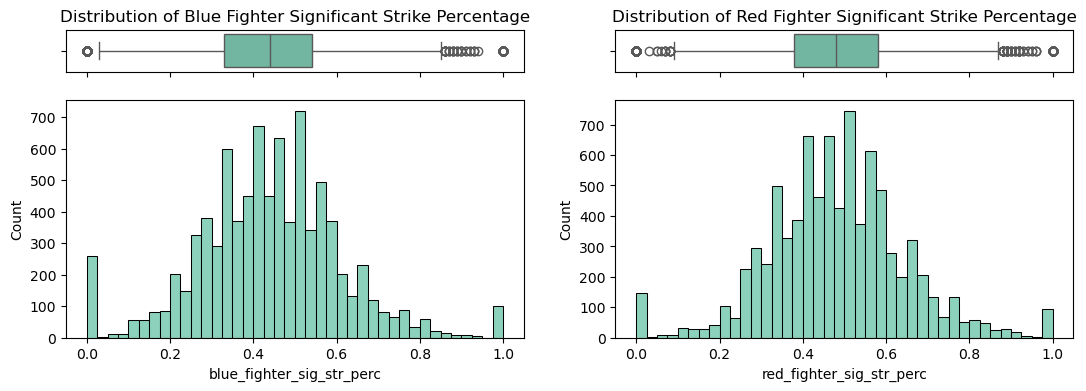

In [99]:
fig, ((bp1, bp2), (hist1, hist2)) = plt.subplots(2, 2, sharex=True, figsize=(13, 4), gridspec_kw={"height_ratios": (.15, .85)})

sns.boxplot(fight_stats.blue_fighter_sig_str_perc, orient='h', ax=bp1)
sns.histplot(data=fight_stats, x='blue_fighter_sig_str_perc', bins=40, ax=hist1)
bp1.set_title('Distribution of Blue Fighter Significant Strike Percentage')

sns.boxplot(fight_stats.red_fighter_sig_str_perc, orient='h', ax=bp2)
sns.histplot(data=fight_stats, x='red_fighter_sig_str_perc', bins=40, ax=hist2)
bp2.set_title('Distribution of Red Fighter Significant Strike Percentage');

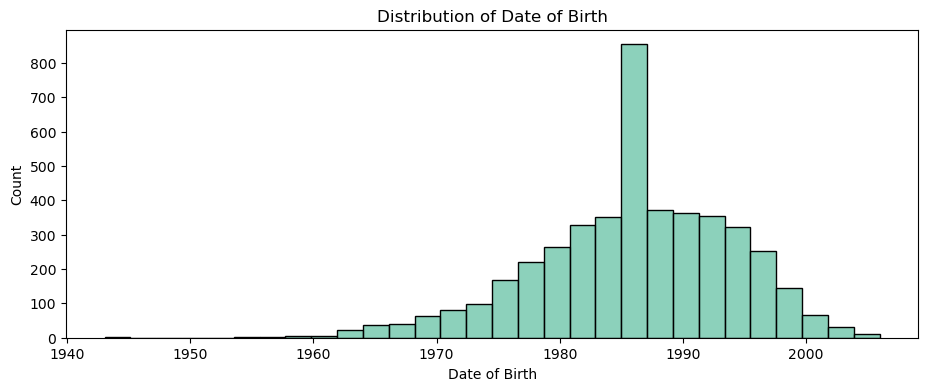

In [100]:
fig = plt.figure(figsize=(11, 4))

sns.histplot(data=fighter_stats, x='dob', bins=30)
plt.title('Distribution of Date of Birth')
plt.xlabel('Date of Birth');

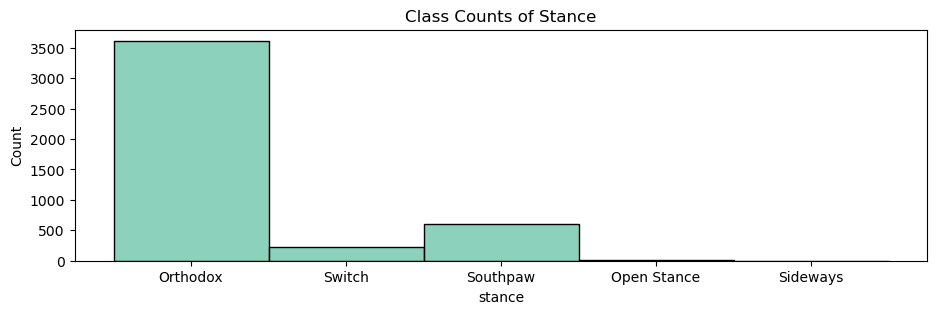

In [101]:
fig = plt.figure(figsize=(11, 3))
sns.histplot(data=fighter_stats, x='stance')
plt.title('Class Counts of Stance');

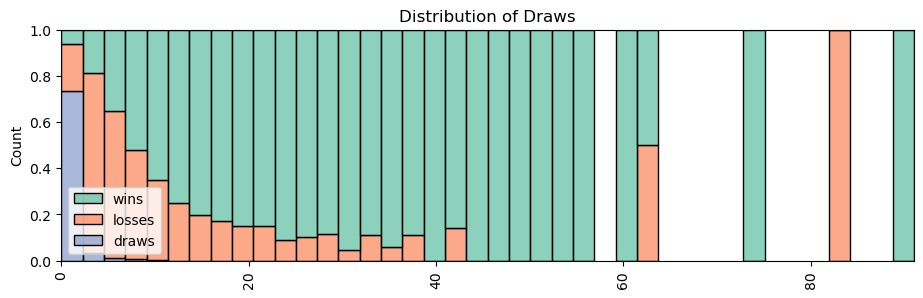

In [102]:
fig = plt.figure(figsize=(11,3))
mask = (fighter_stats.wins < 100) & (fighter_stats.losses < 100)
sns.histplot(data=fighter_stats.loc[mask, ['wins', 'losses', 'draws']], bins=40, multiple='fill')
plt.title('Distribution of Draws')
plt.xticks(rotation=90);

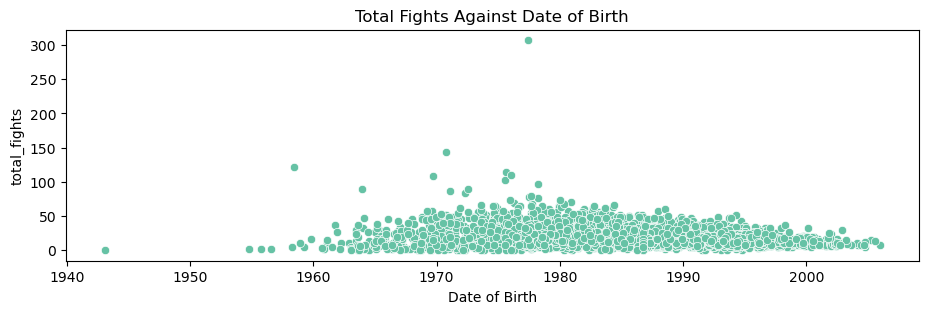

In [103]:
fig = plt.figure(figsize=(11, 3))
sns.scatterplot(data=fighter_stats, x='dob', y='total_fights')
plt.title('Total Fights Against Date of Birth')
plt.xlabel('Date of Birth');

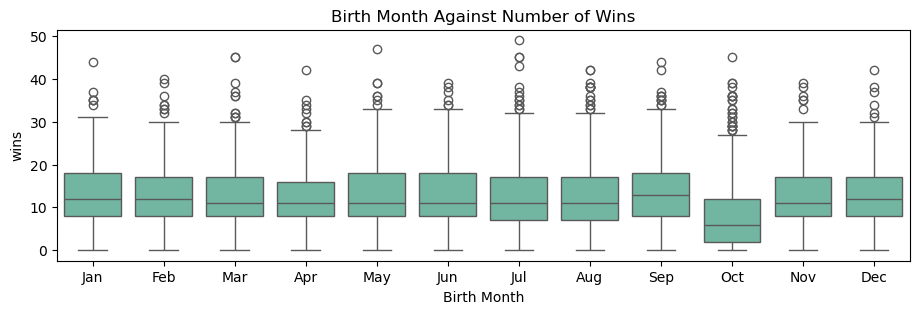

In [104]:
fig = plt.figure(figsize=(11, 3))
mask = (fighter_stats.wins < 50) & (fighter_stats.losses < 50)
sns.boxplot(data=fighter_stats[mask], x='birth_month', y='wins')
plt.title('Birth Month Against Number of Wins')
plt.xlabel('Birth Month')
plt.xticks(range(12), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']);

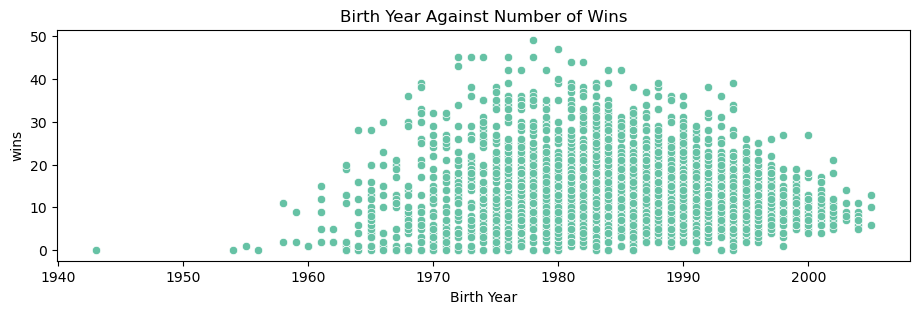

In [105]:
fig = plt.figure(figsize=(11, 3))
mask = (fighter_stats.wins < 50) & (fighter_stats.losses < 50)
sns.scatterplot(data=fighter_stats[mask], x='birth_year', y='wins')
plt.title('Birth Year Against Number of Wins')
plt.xlabel('Birth Year');